In [1]:
!pip install skimpy pyngrok mlflow mlflow-skinny shap causalml econml

In [2]:
import pandas as pd
import numpy as np
import scipy.stats as ss
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import skimpy as sk
from pyngrok import ngrok


from sklearn.preprocessing import *
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import *
from sklearn.decomposition import PCA
from sklearn.cluster import HDBSCAN
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.base import clone

import joblib

In [3]:
train_values = pd.read_csv("train_values.csv")

In [4]:
train_values

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,0
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,0
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,0
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,0
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260596,688636,25,1335,1621,1,55,6,3,n,r,...,0,0,0,0,0,0,0,0,0,0
260597,669485,17,715,2060,2,0,6,5,t,r,...,0,0,0,0,0,0,0,0,0,0
260598,602512,17,51,8163,3,55,6,7,t,r,...,0,0,0,0,0,0,0,0,0,0
260599,151409,26,39,1851,2,10,14,6,t,r,...,0,0,0,0,0,0,0,0,0,0


In [5]:
train_labels = pd.read_csv("train_labels.csv")

In [6]:
train_labels

,building_id,damage_grade
0,802906,3
1,28830,2
2,94947,3
3,590882,2
4,201944,3
...,...,...
260596,688636,2
260597,669485,3
260598,602512,3
260599,151409,2


In [7]:
#Getting All the labels into the training labels
train_df = pd.merge(train_values, train_labels, on="building_id", how="inner")
train_df

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260596,688636,25,1335,1621,1,55,6,3,n,r,...,0,0,0,0,0,0,0,0,0,2
260597,669485,17,715,2060,2,0,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
260598,602512,17,51,8163,3,55,6,7,t,r,...,0,0,0,0,0,0,0,0,0,3
260599,151409,26,39,1851,2,10,14,6,t,r,...,0,0,0,0,0,0,0,0,0,2


In [8]:
train_df.describe()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
count,2.606010e+05,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,...,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000
mean,5.256755e+05,13.900353,701.074685,6257.876148,2.129723,26.535029,8.018051,5.434365,0.088645,0.761935,...,0.033626,0.008101,0.000940,0.000361,0.001071,0.000188,0.000146,0.000088,0.005119,2.238272
std,3.045450e+05,8.033617,412.710734,3646.369645,0.727665,73.565937,4.392231,1.918418,0.284231,0.425900,...,0.180265,0.089638,0.030647,0.018989,0.032703,0.013711,0.012075,0.009394,0.071364,0.611814
min,4.000000e+00,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.611900e+05,7.000000,350.000000,3073.000000,2.000000,10.000000,5.000000,4.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,5.257570e+05,12.000000,702.000000,6270.000000,2.000000,15.000000,7.000000,5.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,7.897620e+05,21.000000,1050.000000,9412.000000,2.000000,30.000000,9.000000,6.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,1.052934e+06,30.000000,1427.000000,12567.000000,9.000000,995.000000,100.000000,32.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000


/tmp/ipython-input-808332658.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train_df["age"])


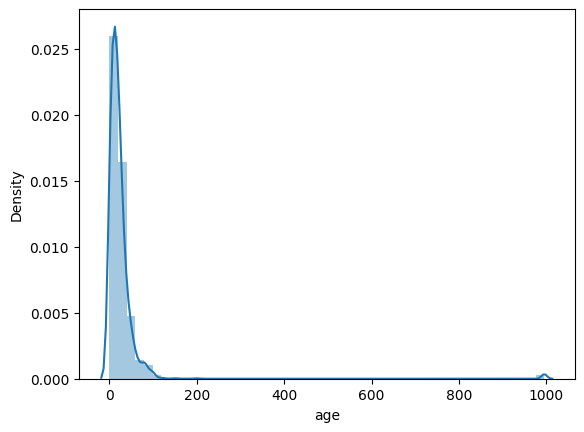

In [9]:
#Age Distribution
sns.distplot(train_df["age"])
#plt.savefig("Age Distribution")
plt.show()

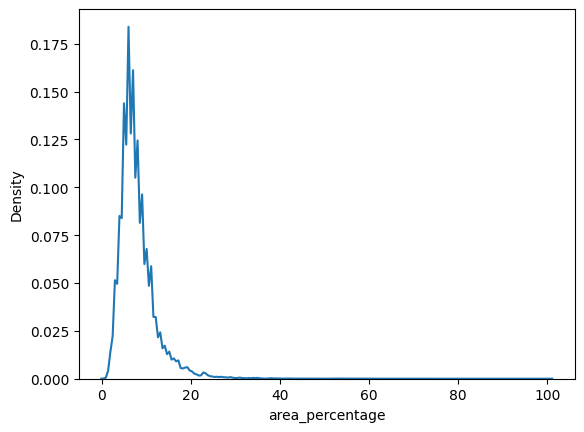

In [10]:
#Area Density
sns.kdeplot(train_df["area_percentage"])
#plt.savefig("Area Kernel Density Estimation")
plt.show()

In [11]:
train_df.columns.astype("object")

Index(['building_id', 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id',
       'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage',
       'land_surface_condition', 'foundation_type', 'roof_type',
       'ground_floor_type', 'other_floor_type', 'position',
       'plan_configuration', 'has_superstructure_adobe_mud',
       'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag',
       'has_superstructure_cement_mortar_stone',
       'has_superstructure_mud_mortar_brick',
       'has_superstructure_cement_mortar_brick', 'has_superstructure_timber',
       'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered',
       'has_superstructure_rc_engineered', 'has_superstructure_other',
       'legal_ownership_status', 'count_families', 'has_secondary_use',
       'has_secondary_use_agriculture', 'has_secondary_use_hotel',
       'has_secondary_use_rental', 'has_secondary_use_institution',
       'has_secondary_use_school', 'has_secondary_use_i

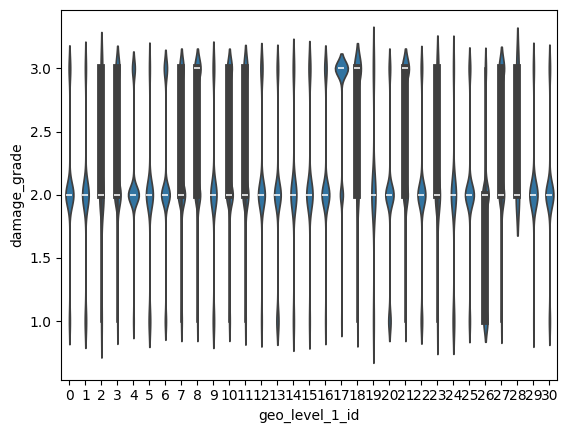

In [12]:
sns.violinplot(data=train_df, x="geo_level_1_id", y="damage_grade")
#plt.savefig("Visualizations/Relation of Damages According to IDs")
plt.show()

## Models and Procedures

In [13]:
#Finding the hidden regimes in Data
vulnerability_features = [
    'count_floors_pre_eq', 'age', 'height_percentage', 'plan_configuration',
    'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone',
    'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone',
    'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick',
    'has_superstructure_timber', 'has_superstructure_bamboo',
    'has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered',
    'has_superstructure_other', 'foundation_type', 'roof_type', 'ground_floor_type',
    'other_floor_type'
]

In [14]:
#One Hot Encoding to view Hidden Regimes
X_vuln = train_df[vulnerability_features].copy()

# Identify categorical columns
categorical_cols = ['plan_configuration', 'foundation_type', 'roof_type',
                    'ground_floor_type', 'other_floor_type']

# One-hot encode
X_vuln = pd.get_dummies(X_vuln, columns=categorical_cols)

In [15]:
#Evaluation Via Silhoette Score
n_clusters = 2

kmeans = KMeans(n_clusters=n_clusters, random_state=42)
X_vuln['structural_regime'] = kmeans.fit_predict(X_vuln)

In [16]:
train_df['structural_regime'] = X_vuln['structural_regime']

In [17]:
train_df

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade,structural_regime
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,3,0
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,2,0
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,3,0
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,2,0
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260596,688636,25,1335,1621,1,55,6,3,n,r,...,0,0,0,0,0,0,0,0,2,0
260597,669485,17,715,2060,2,0,6,5,t,r,...,0,0,0,0,0,0,0,0,3,0
260598,602512,17,51,8163,3,55,6,7,t,r,...,0,0,0,0,0,0,0,0,3,0
260599,151409,26,39,1851,2,10,14,6,t,r,...,0,0,0,0,0,0,0,0,2,0


## Measuring Silhouette Scores

In [18]:
#Normalizing Valuesfor Decomposition
numeric_cols = ['count_floors_pre_eq', 'age', 'height_percentage']
scaler = StandardScaler()
X_vuln[numeric_cols] = scaler.fit_transform(X_vuln[numeric_cols])

Code (Takes Way Too long to Plot):

"""
pca = PCA(n_components=0.95, random_state=42)  # keep 95% variance
X_reduced = pca.fit_transform(X_vuln)


range_k = range(2, 8)
scores = []

for k in range_k:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_reduced)
    score = silhouette_score(X_reduced, labels)
    scores.append(score)
    print(f"K={k}, Silhouette Score={score:.4f}")
"""

Output:
K=2, Silhouette Score=0.3086
K=3, Silhouette Score=0.3219
K=4, Silhouette Score=0.2800
K=5, Silhouette Score=0.2458
K=6, Silhouette Score=0.2578
K=7, Silhouette Score=0.2374

Code For Plot:

#Also Measuring for the Dublin scores
plt.plot(range_k, scores)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters')
plt.grid(True)
#plt.savefig("Silhouette Score Plot")
plt.show()

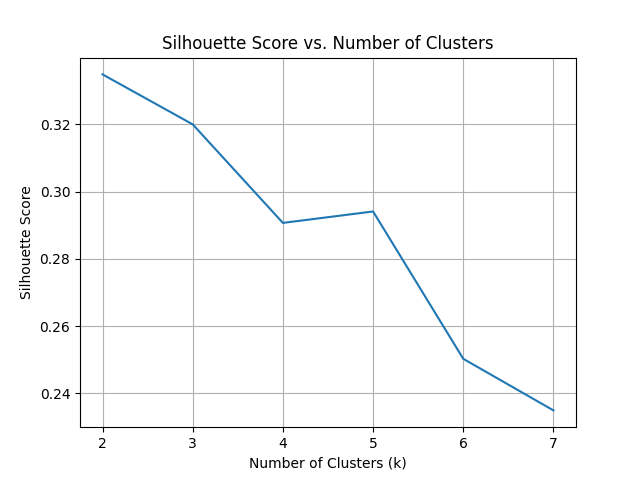

In [19]:
#Label Encoding All of the string type features
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()

encoder = LabelEncoder()
for col in categorical_cols:
    train_df[col] = encoder.fit_transform(train_df[[col]])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,

## Data Engineering the test set

In [20]:
test_df = pd.read_csv("test_values.csv")
test_df

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
0,300051,17,596,11307,3,20,7,6,t,r,...,0,0,0,0,0,0,0,0,0,0
1,99355,6,141,11987,2,25,13,5,t,r,...,1,0,0,0,0,0,0,0,0,0
2,890251,22,19,10044,2,5,4,5,t,r,...,0,0,0,0,0,0,0,0,0,0
3,745817,26,39,633,1,0,19,3,t,r,...,0,0,1,0,0,0,0,0,0,0
4,421793,17,289,7970,3,15,8,7,t,r,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86863,310028,4,605,3623,3,70,20,6,t,r,...,1,0,0,0,0,0,0,0,0,0
86864,663567,10,1407,11907,3,25,6,7,n,r,...,0,0,0,0,0,0,0,0,0,0
86865,1049160,22,1136,7712,1,50,3,3,t,r,...,0,0,0,0,0,0,0,0,0,0
86866,442785,6,1041,912,2,5,9,5,t,r,...,0,0,0,0,0,0,0,0,0,0


In [21]:
#Label Encoding All of the string type features
categorical_cols = test_df.select_dtypes(include=['object']).columns.tolist()

encoder = LabelEncoder()
for col in categorical_cols:
    test_df[col] = encoder.fit_transform(test_df[[col]])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,

In [22]:
test_df

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
0,300051,17,596,11307,3,20,7,6,2,2,...,0,0,0,0,0,0,0,0,0,0
1,99355,6,141,11987,2,25,13,5,2,2,...,1,0,0,0,0,0,0,0,0,0
2,890251,22,19,10044,2,5,4,5,2,2,...,0,0,0,0,0,0,0,0,0,0
3,745817,26,39,633,1,0,19,3,2,2,...,0,0,1,0,0,0,0,0,0,0
4,421793,17,289,7970,3,15,8,7,2,2,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86863,310028,4,605,3623,3,70,20,6,2,2,...,1,0,0,0,0,0,0,0,0,0
86864,663567,10,1407,11907,3,25,6,7,0,2,...,0,0,0,0,0,0,0,0,0,0
86865,1049160,22,1136,7712,1,50,3,3,2,2,...,0,0,0,0,0,0,0,0,0,0
86866,442785,6,1041,912,2,5,9,5,2,2,...,0,0,0,0,0,0,0,0,0,0


In [23]:
test_vulnerability_features = [
    'count_floors_pre_eq', 'age', 'height_percentage', 'plan_configuration',
    'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone',
    'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone',
    'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick',
    'has_superstructure_timber', 'has_superstructure_bamboo',
    'has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered',
    'has_superstructure_other', 'foundation_type', 'roof_type', 'ground_floor_type',
    'other_floor_type'
]

In [24]:
#Sanity Check
any(col in test_df.columns for col in test_vulnerability_features)

True

In [25]:
#One Hot Encoding to view Hidden Regimes
X_test_vuln = test_df[vulnerability_features].copy()

# Identify categorical columns
categorical_cols = ['plan_configuration', 'foundation_type', 'roof_type',
                    'ground_floor_type', 'other_floor_type']

# One-hot encode
X_test_vuln = pd.get_dummies(X_test_vuln, columns=categorical_cols)

In [26]:
n_clusters = 2

test_kmeans = KMeans(n_clusters=n_clusters, random_state=42)
X_test_vuln['structural_regime'] = kmeans.fit_predict(X_test_vuln)
test_df['structural_regime'] = X_test_vuln['structural_regime']

In [27]:
test_df

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,structural_regime
0,300051,17,596,11307,3,20,7,6,2,2,...,0,0,0,0,0,0,0,0,0,0
1,99355,6,141,11987,2,25,13,5,2,2,...,0,0,0,0,0,0,0,0,0,0
2,890251,22,19,10044,2,5,4,5,2,2,...,0,0,0,0,0,0,0,0,0,0
3,745817,26,39,633,1,0,19,3,2,2,...,0,1,0,0,0,0,0,0,0,0
4,421793,17,289,7970,3,15,8,7,2,2,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86863,310028,4,605,3623,3,70,20,6,2,2,...,0,0,0,0,0,0,0,0,0,0
86864,663567,10,1407,11907,3,25,6,7,0,2,...,0,0,0,0,0,0,0,0,0,0
86865,1049160,22,1136,7712,1,50,3,3,2,2,...,0,0,0,0,0,0,0,0,0,0
86866,442785,6,1041,912,2,5,9,5,2,2,...,0,0,0,0,0,0,0,0,0,0


## Checking for Potential Data Imbalances and Distribution Inefficiencies

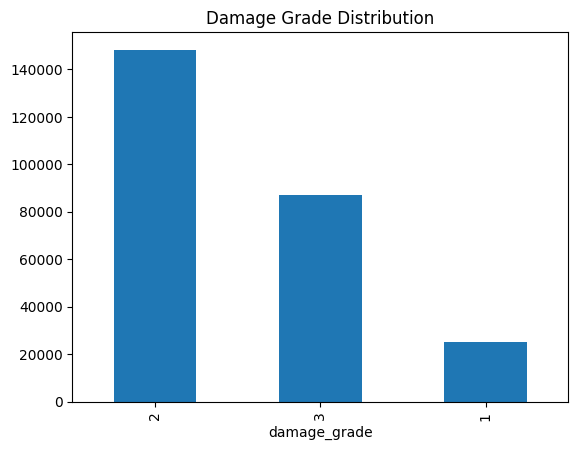

In [28]:
train_df["damage_grade"].value_counts().plot(kind="bar")
plt.savefig("Damage Grade Distribution")
plt.title("Damage Grade Distribution")
plt.show()

##Modelling

In [29]:
X = train_df.drop(columns=["damage_grade"])
y = train_df["damage_grade"]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

In [31]:
lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        multi_class="multinomial",
        solver="lbfgs",
        penalty="l2",
        C=1.0,
        class_weight="balanced",
        random_state=42
    ))
])

rfr = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=4,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

gbr = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    validation_fraction=0.1,
    n_iter_no_change=50,
    tol=1e-4,
    criterion="friedman_mse",
    min_samples_split=5,
    min_samples_leaf=4,
    max_features="sqrt",
    random_state=42
)

mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate="adaptive",
        max_iter=1500,
        early_stopping=True,
        random_state=42
    ))
])

xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

lgb = LGBMClassifier(
    objective="multiclass",
    num_class=3,
    num_leaves=31,
    max_depth=6,
    learning_rate=0.1,
    n_estimators=1000,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [32]:
mlflow.set_experiment("Trained Models without GroupedCV")

models = {
    "Logistic Regression": lr,
    "Random Forest": rfr,
    "Gradient Boosting": gbr,
    "Multilayer Perceptron": mlp,
    "XGBoost": xgb,
    "LightGBM": lgb
}

for name, model in models.items():

    with mlflow.start_run(run_name=name):

        if name == "XGBoost" or name == "LightGBM":
            y_train_used = y_train - 1
            y_test_used = y_test - 1
        else:
            y_train_used = y_train
            y_test_used = y_test

        model.fit(X_train, y_train_used)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test_used, y_pred)
        precision_macro = precision_score(y_test_used, y_pred, average="macro", zero_division=0)
        recall_macro = recall_score(y_test_used, y_pred, average="macro", zero_division=0)
        f1_macro = f1_score(y_test_used, y_pred, average="macro", zero_division=0)

        precision_weighted = precision_score(y_test_used, y_pred, average="weighted", zero_division=0)
        recall_weighted = recall_score(y_test_used, y_pred, average="weighted", zero_division=0)
        f1_weighted = f1_score(y_test_used, y_pred, average="weighted", zero_division=0)

        qwk = cohen_kappa_score(y_test_used, y_pred, weights="quadratic")

        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("precision_macro", precision_macro)
        mlflow.log_metric("recall_macro", recall_macro)
        mlflow.log_metric("f1_macro", f1_macro)
        mlflow.log_metric("precision_weighted", precision_weighted)
        mlflow.log_metric("recall_weighted", recall_weighted)
        mlflow.log_metric("f1_weighted", f1_weighted)
        mlflow.log_metric("quadratic_weighted_kappa", qwk)

        if hasattr(model, "get_params"):
            mlflow.log_params(model.get_params())

        report = classification_report(y_test_used, y_pred, zero_division=0)
        with open(f"{name}_classification_report.txt", "w") as f:
            f.write(report)
        mlflow.log_artifact(f"{name}_classification_report.txt")

        cm = confusion_matrix(y_test_used, y_pred)

        plt.figure()
        sns.heatmap(cm, annot=True, fmt="d")
        plt.title(f"{name} Confusion Matrix")
        plt.ylabel("True Label")
        plt.xlabel("Predicted Label")
        plt.savefig(f"{name}_confusion_matrix.png")
        plt.close()

        mlflow.log_artifact(f"{name}_confusion_matrix.png")

        if name == "XGBoost":
            mlflow.xgboost.log_model(model, "model")
        elif name == "LightGBM":
            mlflow.lightgbm.log_model(model, "model")
        else:
            mlflow.sklearn.log_model(model, "model")

        print(f"\n{name} Results")
        print(f"Accuracy: {acc:.4f}")
        print(f"Precision (Macro): {precision_macro:.4f}")
        print(f"Recall (Macro): {recall_macro:.4f}")
        print(f"F1 (Macro): {f1_macro:.4f}")
        print(f"Precision (Weighted): {precision_weighted:.4f}")
        print(f"Recall (Weighted): {recall_weighted:.4f}")
        print(f"F1 (Weighted): {f1_weighted:.4f}")
        print(f"Quadratic Weighted Kappa: {qwk:.4f}")
        print("\nClassification Report:\n")
        print(report)
        print("Confusion Matrix:\n", cm)
        print(f"\n{name} logged successfully.")

2026/02/25 09:20:36 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/02/25 09:20:36 INFO mlflow.store.db.utils: Updating database tables
2026/02/25 09:20:39 INFO mlflow.tracking.fluent: Experiment with name 'Trained Models without GroupedCV' does not exist. Creating a new experiment.
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
2026/02/25 09:20:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/25 09:20:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative 


Logistic Regression Results
Accuracy: 0.5105
Precision (Macro): 0.5070
Recall (Macro): 0.5231
F1 (Macro): 0.5039
Precision (Weighted): 0.5436
Recall (Weighted): 0.5105
F1 (Weighted): 0.5125
Quadratic Weighted Kappa: 0.3275

Classification Report:

              precision    recall  f1-score   support

           1       0.47      0.50      0.49      5025
           2       0.63      0.45      0.52     29652
           3       0.42      0.62      0.50     17444

    accuracy                           0.51     52121
   macro avg       0.51      0.52      0.50     52121
weighted avg       0.54      0.51      0.51     52121

Confusion Matrix:
 [[ 2533  1496   996]
 [ 2523 13341 13788]
 [  304  6408 10732]]

Logistic Regression logged successfully.


2026/02/25 09:23:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/25 09:23:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Random Forest Results
Accuracy: 0.5832
Precision (Macro): 0.5492
Recall (Macro): 0.6017
F1 (Macro): 0.5649
Precision (Weighted): 0.6089
Recall (Weighted): 0.5832
F1 (Weighted): 0.5870
Quadratic Weighted Kappa: 0.4319

Classification Report:

              precision    recall  f1-score   support

           1       0.44      0.62      0.52      5025
           2       0.70      0.54      0.61     29652
           3       0.51      0.64      0.57     17444

    accuracy                           0.58     52121
   macro avg       0.55      0.60      0.56     52121
weighted avg       0.61      0.58      0.59     52121

Confusion Matrix:
 [[ 3132  1239   654]
 [ 3442 16150 10060]
 [  504  5823 11117]]

Random Forest logged successfully.


2026/02/25 09:36:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/25 09:36:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...


Multilayer Perceptron Results
Accuracy: 0.6502
Precision (Macro): 0.6102
Recall (Macro): 0.5833
F1 (Macro): 0.5950
Precision (Weighted): 0.6460
Recall (Weighted): 0.6502
F1 (Weighted): 0.6471
Quadratic Weighted Kappa: 0.4702

Classification Report:

              precision    recall  f1-score   support

           1       0.54      0.45      0.49      5025
           2       0.69      0.73      0.71     29652
           3       0.61      0.57      0.58     17444

    accuracy                           0.65     52121
   macro avg       0.61      0.58      0.60     52121
weighted avg       0.65      0.65      0.65     52121

Confusion Matrix:
 [[ 2264  2482   279]
 [ 1736 21758  6158]
 [  218  7360  9866]]

Multilayer Perceptron logged successfully.


2026/02/25 09:42:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



XGBoost Results
Accuracy: 0.7307
Precision (Macro): 0.7044
Recall (Macro): 0.6640
F1 (Macro): 0.6811
Precision (Weighted): 0.7284
Recall (Weighted): 0.7307
F1 (Weighted): 0.7272
Quadratic Weighted Kappa: 0.5983

Classification Report:

              precision    recall  f1-score   support

           0       0.64      0.53      0.58      5025
           1       0.74      0.82      0.78     29652
           2       0.73      0.64      0.68     17444

    accuracy                           0.73     52121
   macro avg       0.70      0.66      0.68     52121
weighted avg       0.73      0.73      0.73     52121

Confusion Matrix:
 [[ 2682  2250    93]
 [ 1355 24207  4090]
 [  141  6108 11195]]

XGBoost logged successfully.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.249829 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1173
[LightGBM] [Info] Number of data points in the train set: 355821, number 

2026/02/25 09:44:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/25 09:44:29 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



LightGBM Results
Accuracy: 0.7288
Precision (Macro): 0.7017
Recall (Macro): 0.6609
F1 (Macro): 0.6781
Precision (Weighted): 0.7265
Recall (Weighted): 0.7288
F1 (Weighted): 0.7251
Quadratic Weighted Kappa: 0.5949

Classification Report:

              precision    recall  f1-score   support

           0       0.64      0.53      0.58      5025
           1       0.74      0.82      0.78     29652
           2       0.73      0.64      0.68     17444

    accuracy                           0.73     52121
   macro avg       0.70      0.66      0.68     52121
weighted avg       0.73      0.73      0.73     52121

Confusion Matrix:
 [[ 2657  2276    92]
 [ 1374 24201  4077]
 [  143  6175 11126]]

LightGBM logged successfully.


##Test Set Prediction

In [33]:
train_df

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade,structural_regime
0,802906,6,487,12198,2,30,6,5,2,2,...,0,0,0,0,0,0,0,0,3,0
1,28830,8,900,2812,2,10,8,7,1,2,...,0,0,0,0,0,0,0,0,2,0
2,94947,21,363,8973,2,10,5,5,2,2,...,0,0,0,0,0,0,0,0,3,0
3,590882,22,418,10694,2,10,6,5,2,2,...,0,0,0,0,0,0,0,0,2,0
4,201944,11,131,1488,3,30,8,9,2,2,...,0,0,0,0,0,0,0,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260596,688636,25,1335,1621,1,55,6,3,0,2,...,0,0,0,0,0,0,0,0,2,0
260597,669485,17,715,2060,2,0,6,5,2,2,...,0,0,0,0,0,0,0,0,3,0
260598,602512,17,51,8163,3,55,6,7,2,2,...,0,0,0,0,0,0,0,0,3,0
260599,151409,26,39,1851,2,10,14,6,2,2,...,0,0,0,0,0,0,0,0,2,0


In [34]:
test_df

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,structural_regime
0,300051,17,596,11307,3,20,7,6,2,2,...,0,0,0,0,0,0,0,0,0,0
1,99355,6,141,11987,2,25,13,5,2,2,...,0,0,0,0,0,0,0,0,0,0
2,890251,22,19,10044,2,5,4,5,2,2,...,0,0,0,0,0,0,0,0,0,0
3,745817,26,39,633,1,0,19,3,2,2,...,0,1,0,0,0,0,0,0,0,0
4,421793,17,289,7970,3,15,8,7,2,2,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86863,310028,4,605,3623,3,70,20,6,2,2,...,0,0,0,0,0,0,0,0,0,0
86864,663567,10,1407,11907,3,25,6,7,0,2,...,0,0,0,0,0,0,0,0,0,0
86865,1049160,22,1136,7712,1,50,3,3,2,2,...,0,0,0,0,0,0,0,0,0,0
86866,442785,6,1041,912,2,5,9,5,2,2,...,0,0,0,0,0,0,0,0,0,0


In [35]:
np.unique(train_df["structural_regime"])

array([0, 1], dtype=int32)

In [36]:
feature_columns = [col for col in test_df.columns]  # adjust if needed
X_test = test_df[feature_columns].copy()

In [37]:
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Compute zero-based offset for XGBoost/LightGBM
label_offset = y.min()

n_classes = len(np.unique(y))
oof_preds = {name: np.zeros((len(X), n_classes)) for name in models}
test_preds = {name: np.zeros((len(X_test), n_classes)) for name in models}

for name, model in models.items():
    print(f"Training {name}")

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

        # Zero-based labels for XGBoost / LightGBM
        if name in ["XGBoost", "LightGBM"]:
            y_train_used = y_train_fold.astype(int) - label_offset
            y_val_used = y_val_fold.astype(int) - label_offset
        else:
            y_train_used = y_train_fold
            y_val_used = y_val_fold

        clf = clone(model)
        clf.fit(X_train, y_train_used)

        # Store OOF predictions
        oof_preds[name][val_idx] = clf.predict_proba(X_val)

        # Store test predictions (average across folds)
        test_preds[name] += clf.predict_proba(X_test) / n_splits

Training Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

Training Random Forest
Training Gradient Boosting
Training Multilayer Perceptron
Training XGBoost
Training LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.074240 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1035
[LightGBM] [Info] Number of data points in the train set: 208480, number of used features: 40
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

In [38]:
weights = {
    "Logistic Regression": 0.05,
    "Random Forest": 0.10,
    "Gradient Boosting": 0.10,
    "Multilayer Perceptron": 0.10,
    "XGBoost": 0.30,
    "LightGBM": 0.35
}

test_ensemble = sum(weights[name] * test_preds[name] for name in weights)
test_final = np.argmax(test_ensemble, axis=1)

In [40]:
subs = pd.DataFrame({
    "building_id": test_df["building_id"],
    "damage_grade": test_final
})
subs.to_csv("submission.csv", index=False)

#Save all of the models via joblib
for name, model in models.items():
    joblib.dump(model, f"{name}_model.pkl")

## Statistical Tests